# Exploratory Data Analysis

The objective of this exploratory analysis is to understand the characteristics of the PhysioNet 2019 ICU cohort, investigate temporal behaviour, quantify informative missingness, and identify patterns that motivate the proposed  deep learning architecture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2

from config import (
    DB_HOST,
    DB_PORT,
    DB_NAME,
    DB_USER,
    DB_PASSWORD
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
conn = psycopg2.connect(
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD
)
#Load Tables
patients = pd.read_sql(
    "SELECT * FROM patients;",
    conn
)

measurements = pd.read_sql(
    "SELECT * FROM clinical_measurements;",
    conn
)

<positron-console-cell-2>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
<positron-console-cell-2>:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2. Dataset Overview
This section establishes the basic shape and structure of the cohort: how many patients, 
how many hourly observations, and what variables are available before any cleaning or modeling.

In [3]:
#Dataset Shape
patients.shape, measurements.shape

((40336, 6), (1552210, 37))

In [4]:
#Checking for duplicates
# Number of unique patients
patients["patient_id"].nunique()

40336

In [5]:
# Number of hourly records (rows in measurements = total patient-hours)
measurements.shape[0]

1552210

In [6]:
# Columns in each table
patients.columns

Index(['patient_id', 'age', 'gender', 'unit1', 'unit2', 'hosp_adm_time'], dtype='str')

In [7]:
measurements.columns

Index(['patient_id', 'iculos', 'hr', 'o2sat', 'temp', 'sbp', 'map', 'dbp',
       'resp', 'etco2', 'baseexcess', 'hco3', 'fio2', 'ph', 'paco2', 'sao2',
       'ast', 'bun', 'alkalinephos', 'calcium', 'chloride', 'creatinine',
       'bilirubin_direct', 'glucose', 'lactate', 'magnesium', 'phosphate',
       'potassium', 'bilirubin_total', 'troponini', 'hct', 'hgb', 'ptt', 'wbc',
       'fibrinogen', 'platelets', 'sepsis_label'],
      dtype='str')

In [8]:
#Checking for the datatypes
patients.dtypes
measurements.dtypes

patient_id            int64
iculos                int64
hr                  float64
o2sat               float64
temp                float64
sbp                 float64
map                 float64
dbp                 float64
resp                float64
etco2               float64
baseexcess          float64
hco3                float64
fio2                float64
ph                  float64
paco2               float64
sao2                float64
ast                 float64
bun                 float64
alkalinephos        float64
calcium             float64
chloride            float64
creatinine          float64
bilirubin_direct    float64
glucose             float64
lactate             float64
magnesium           float64
phosphate           float64
potassium           float64
bilirubin_total     float64
troponini           float64
hct                 float64
hgb                 float64
ptt                 float64
wbc                 float64
fibrinogen          float64
platelets           

In [9]:
colors = ["#3594cc", "#8cc5e3", "#ea801c", "#f0b077"]

# 3. Missingness Analysis (Informative Missingness)

Traditional machine learning treats missing data as a nuisance to be imputed away.

Our hypothesis is different: in ICU environments, laboratory tests are ordered selectively by clinicians based on
suspected patient status. Therefore, the absence of a measurement itself carries clinical information.

This section quantifies missingness across the PhysioNet cohort and motivates an informative missingness
gating mechanism in the model architecture.

In [10]:
import matplotlib.pyplot as plt
from config import PROJECT_ROOT

## 3.1 Overall Missingness

Bar chart of missingness across all clinical variables. This establishes the baseline case for a gating
network that can learn from presence/absence patterns rather than treating missingness as pure noise.

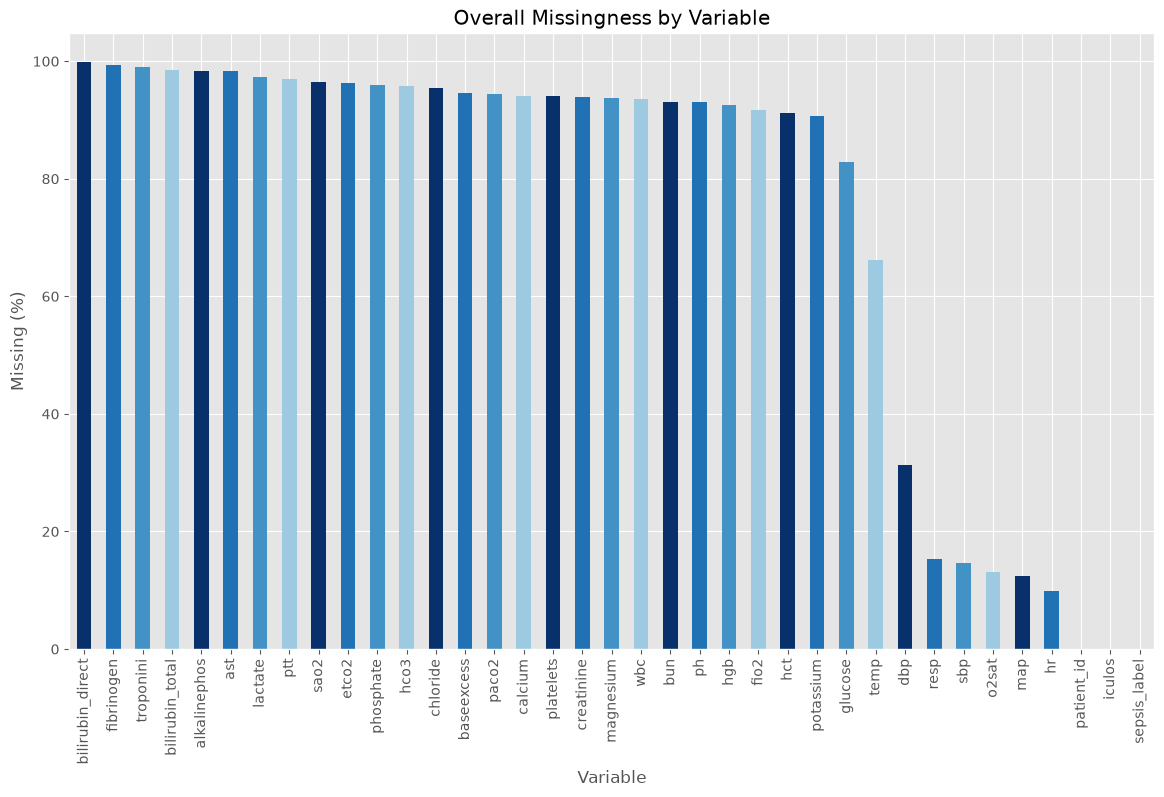

In [11]:
#3.1 Overall Missingness
missing_pct = measurements.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

plt.figure(figsize=(14,8))
missing_pct.plot(kind="bar", color = ["#08306b", "#2171b5", "#4292c6", "#9ecae1"])
plt.ylabel("Missing (%)")
plt.xlabel("Variable")
plt.title("Overall Missingness by Variable")
plt.xticks(rotation=90)
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "overall_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.2 Missingness Heatmap

Missingness pattern for a random sample of patients, visualized as a binary matrix. This illustrates the
irregular, non-random sampling intervals typical of ICU monitoring.

In [12]:
#3.2 Missingness Heatmap (random patients)
#Sample is too big to map all
random_ids = measurements["patient_id"].drop_duplicates().sample(30, random_state=42)
sample = measurements[measurements["patient_id"].isin(random_ids)]

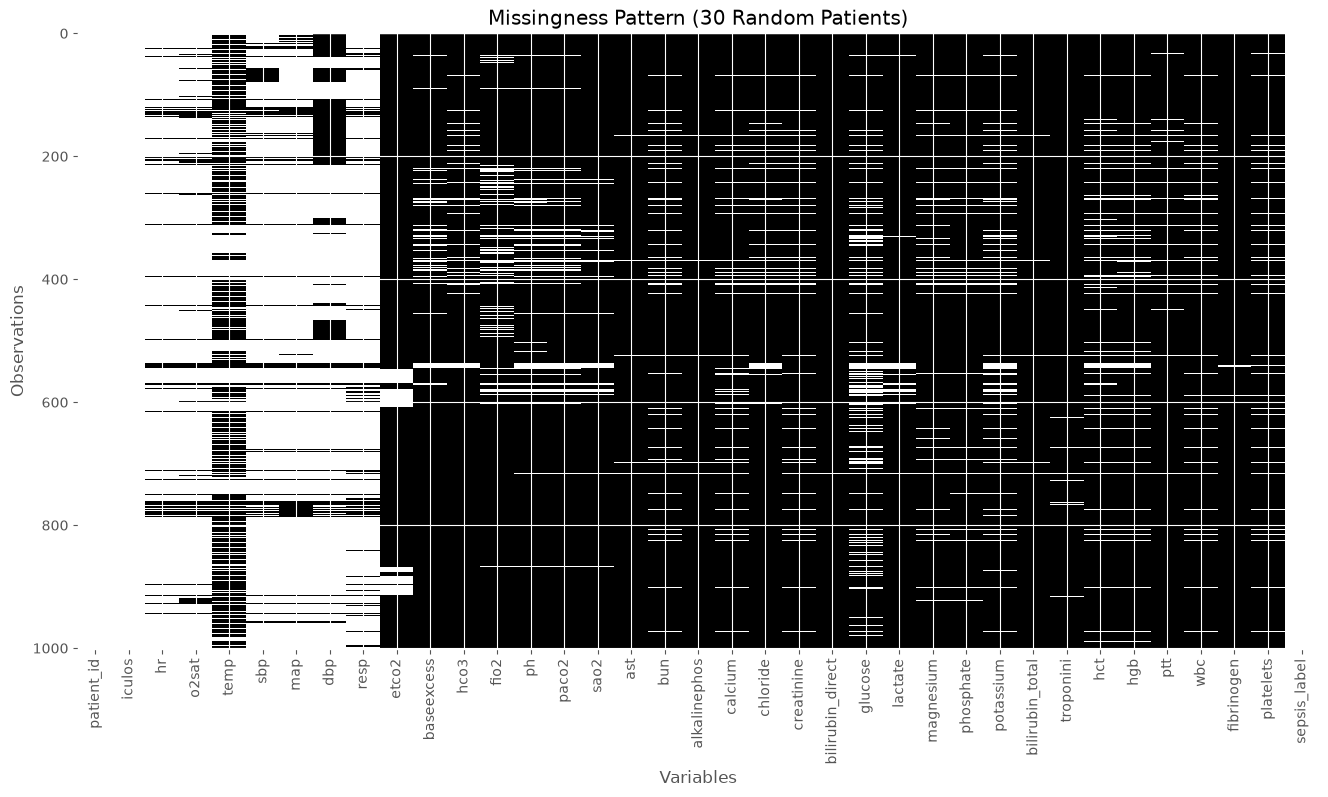

In [13]:
plt.figure(figsize=(16,8))
plt.imshow(sample.isnull(), aspect="auto", cmap="Greys", interpolation="nearest")
plt.title("Missingness Pattern (30 Random Patients)")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.xticks(range(len(sample.columns)), sample.columns, rotation=90)
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "missingness_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.3 Missingness by Feature Category

Vitals (HR, MAP, SBP, Resp, Temp, O2Sat) are measured near-continuously, while labs (Lactate, Bilirubin,
Creatinine, TroponinI, etc.) are ordered intermittently. This split shows that laboratory values disappear
far more often than vital signs, which has direct implications for how each feature type should be handled.

In [14]:
# Vitals and Labs

vitals = [
    "hr",
    "o2sat",
    "temp",
    "sbp",
    "map",
    "dbp",
    "resp",
    "etco2"
]

labs = [
    "baseexcess",
    "hco3",
    "fio2",
    "ph",
    "paco2",
    "sao2",
    "ast",
    "bun",
    "alkalinephos",
    "calcium",
    "chloride",
    "creatinine",
    "bilirubin_direct",
    "glucose",
    "lactate",
    "magnesium",
    "phosphate",
    "potassium",
    "bilirubin_total",
    "troponini",
    "hct",
    "hgb",
    "ptt",
    "wbc",
    "fibrinogen",
    "platelets"
]

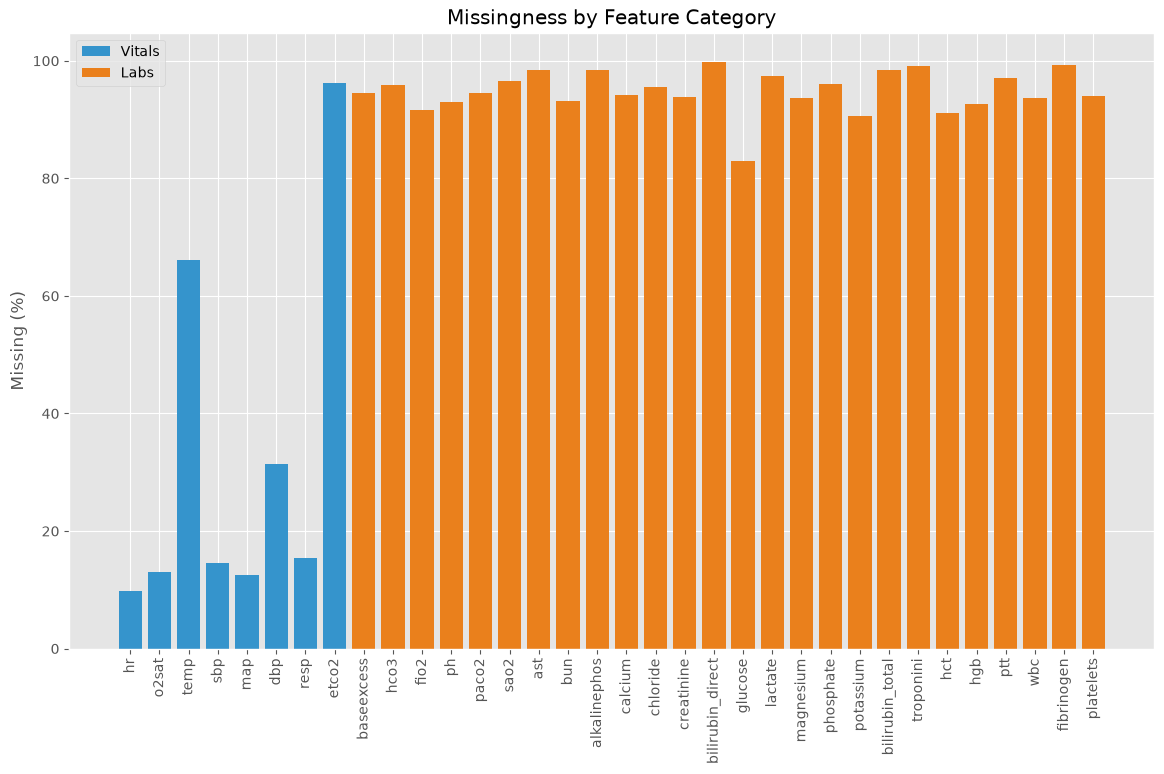

In [15]:
# Missingness by Feature Category
vitals_missing = measurements[vitals].isnull().mean() * 100
labs_missing = measurements[labs].isnull().mean() * 100

plt.figure(figsize=(14,8))
plt.bar(vitals_missing.index, vitals_missing.values, color=colors[0], label="Vitals")
plt.bar(labs_missing.index, labs_missing.values, color=colors[2], label="Labs")
plt.ylabel("Missing (%)")
plt.title("Missingness by Feature Category")
plt.xticks(rotation=90)
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "feature_missingness_by_category.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

## 3.4 Missingness vs Sepsis

Are septic patients monitored more frequently than non-septic patients? If so, missingness itself becomes
a predictive signal rather than noise to be discarded — the core justification for informative missingness
gating.

In [16]:
 #Missingness vs Sepsis
missing_vs_sepsis = pd.DataFrame({
    col: measurements.groupby("sepsis_label")[col].apply(lambda x: x.isnull().mean() * 100)
    for col in labs
}).T

missing_vs_sepsis.columns = ["No Sepsis (%)", "Sepsis (%)"]
missing_vs_sepsis = missing_vs_sepsis.sort_values("Sepsis (%)")
missing_vs_sepsis

,No Sepsis (%),Sepsis (%)
glucose,82.915041,81.763147
fio2,91.842453,82.017481
ph,93.187469,86.638487
potassium,90.760050,86.814013
paco2,94.545278,88.698238
hct,91.189364,88.777045
baseexcess,94.667105,89.769308
hgb,92.658503,90.381860
bun,93.174545,90.944261
calcium,94.166020,91.388451


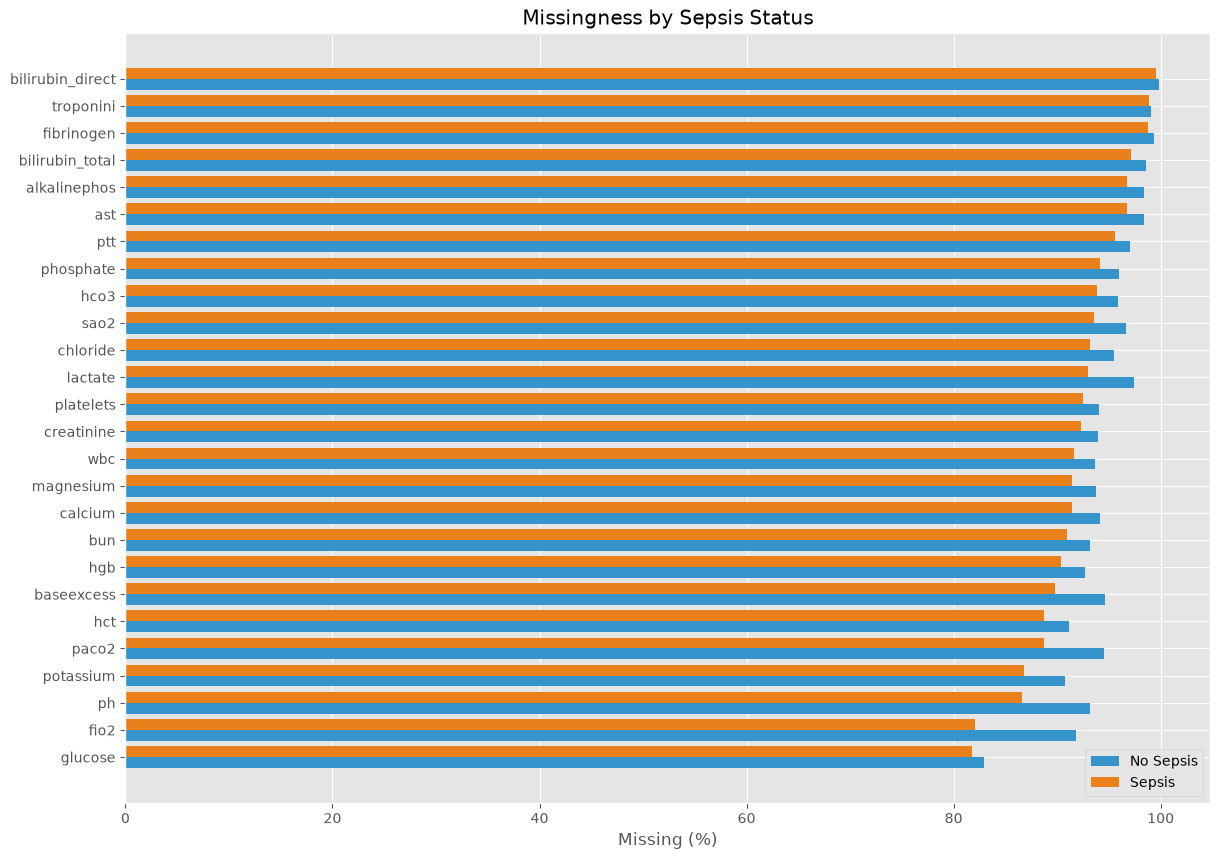

In [17]:
x = range(len(missing_vs_sepsis))

plt.figure(figsize=(14,10))
plt.barh([i - 0.2 for i in x], missing_vs_sepsis["No Sepsis (%)"], height=0.4, color=colors[0], label="No Sepsis")
plt.barh([i + 0.2 for i in x], missing_vs_sepsis["Sepsis (%)"], height=0.4, color=colors[2], label="Sepsis")
plt.yticks(x, missing_vs_sepsis.index)
plt.xlabel("Missing (%)")
plt.title("Missingness by Sepsis Status")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "missingness_vs_sepsis.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

## 3.5 Time Since Last Measurement

For key deterioration markers (Lactate, Creatinine, Bilirubin, WBC), we compute hours elapsed since the
last recorded value. This directly motivates a gating mechanism that weighs "staleness" of information,
not just its presence or absence.

In [18]:
#Time Since Last Measurement
target_cols = ["lactate", "creatinine", "bilirubin_total", "wbc"]

df = measurements.sort_values(["patient_id", "iculos"]).copy()

for col in target_cols:
    last_seen_hour = df["iculos"].where(df[col].notna())
    last_seen_hour = last_seen_hour.groupby(df["patient_id"]).ffill()
    df[f"{col}_hrs_since"] = df["iculos"] - last_seen_hour

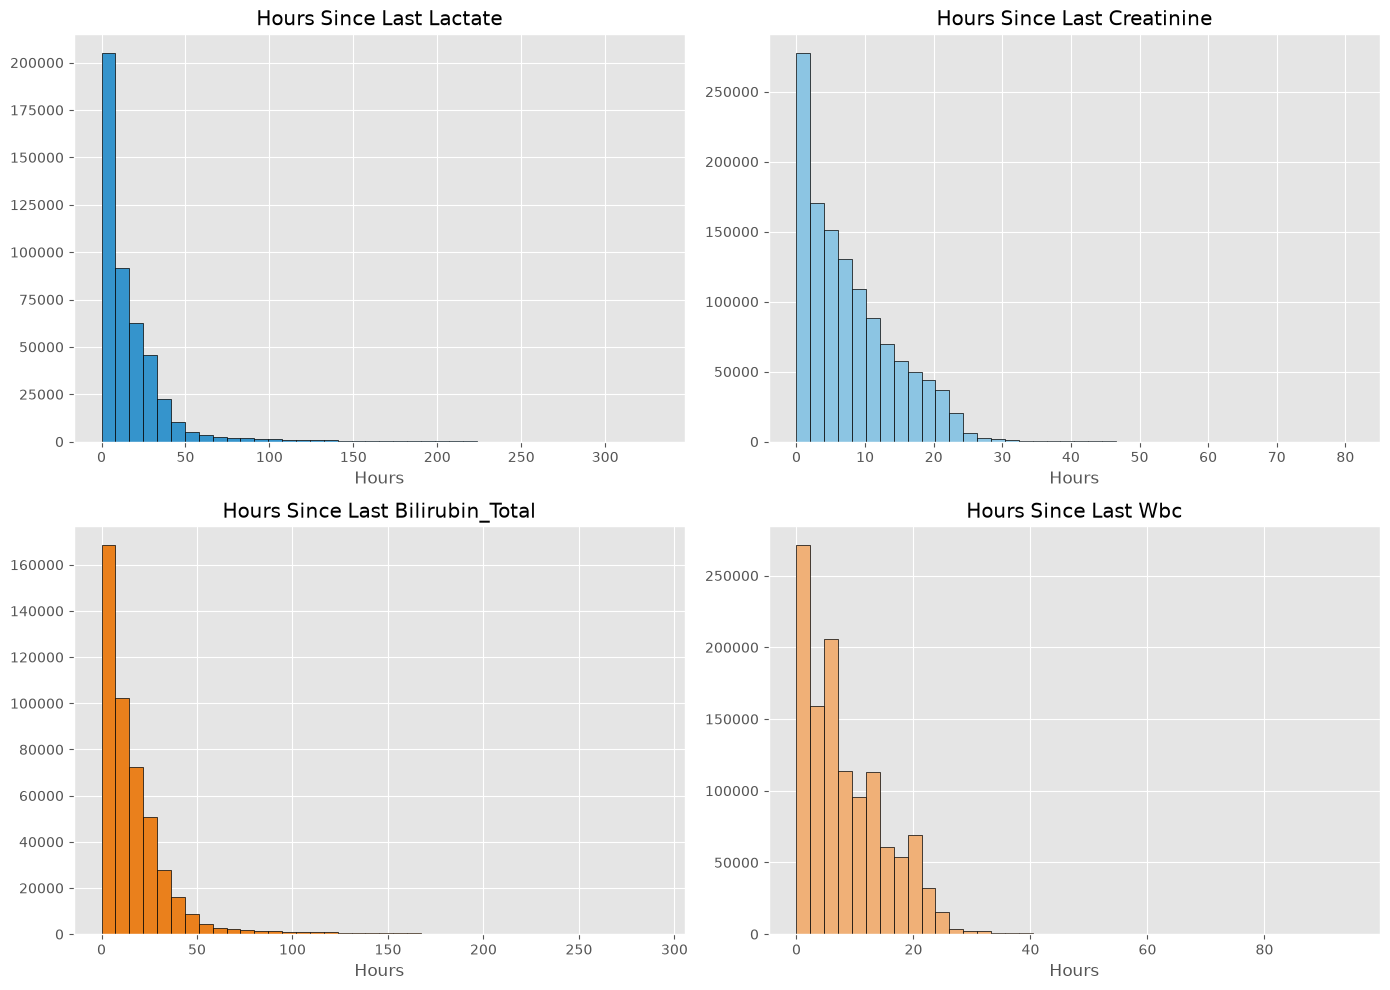

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    axes[i].hist(df[f"{col}_hrs_since"].dropna(), bins=40, color=colors[i], edgecolor="black")
    axes[i].set_title(f"Hours Since Last {col.title()}")
    axes[i].set_xlabel("Hours")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "time_since_last_measurement.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Temporal Dynamics

Having established how missingness behaves, we now turn from absence to the physiology itself: how vital
signs evolve over an ICU stay, and whether their trajectories differ between patients who develop sepsis
and those who do not.

## 4.1 ICU Length of Stay Distribution

Histogram of ICULOS (ICU length of stay in hours) across the cohort. This informs the choice of sliding
window size for the temporal model.

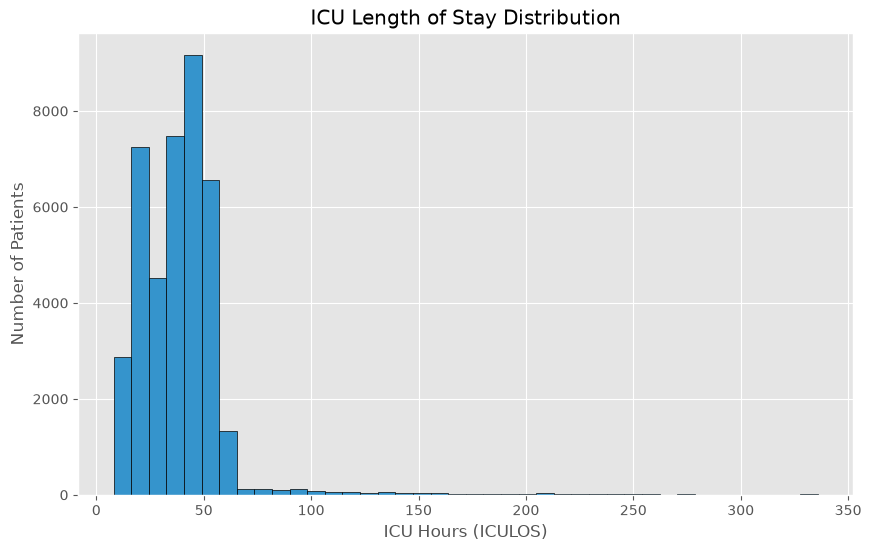

In [20]:
#4. Temporal Dynamics
# ICU Length Distribution
icu_length = measurements.groupby("patient_id")["iculos"].max()

plt.figure(figsize=(10,6))
icu_length.hist(bins=40, color=colors[0], edgecolor="black")
plt.title("ICU Length of Stay Distribution")
plt.xlabel("ICU Hours (ICULOS)")
plt.ylabel("Number of Patients")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "icu_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.2 Vital Sign Distributions

Marginal distributions of HR, MAP, Resp, Temp, and O2Sat across all observations, establishing normal
ranges and identifying outliers or skew before any modeling.

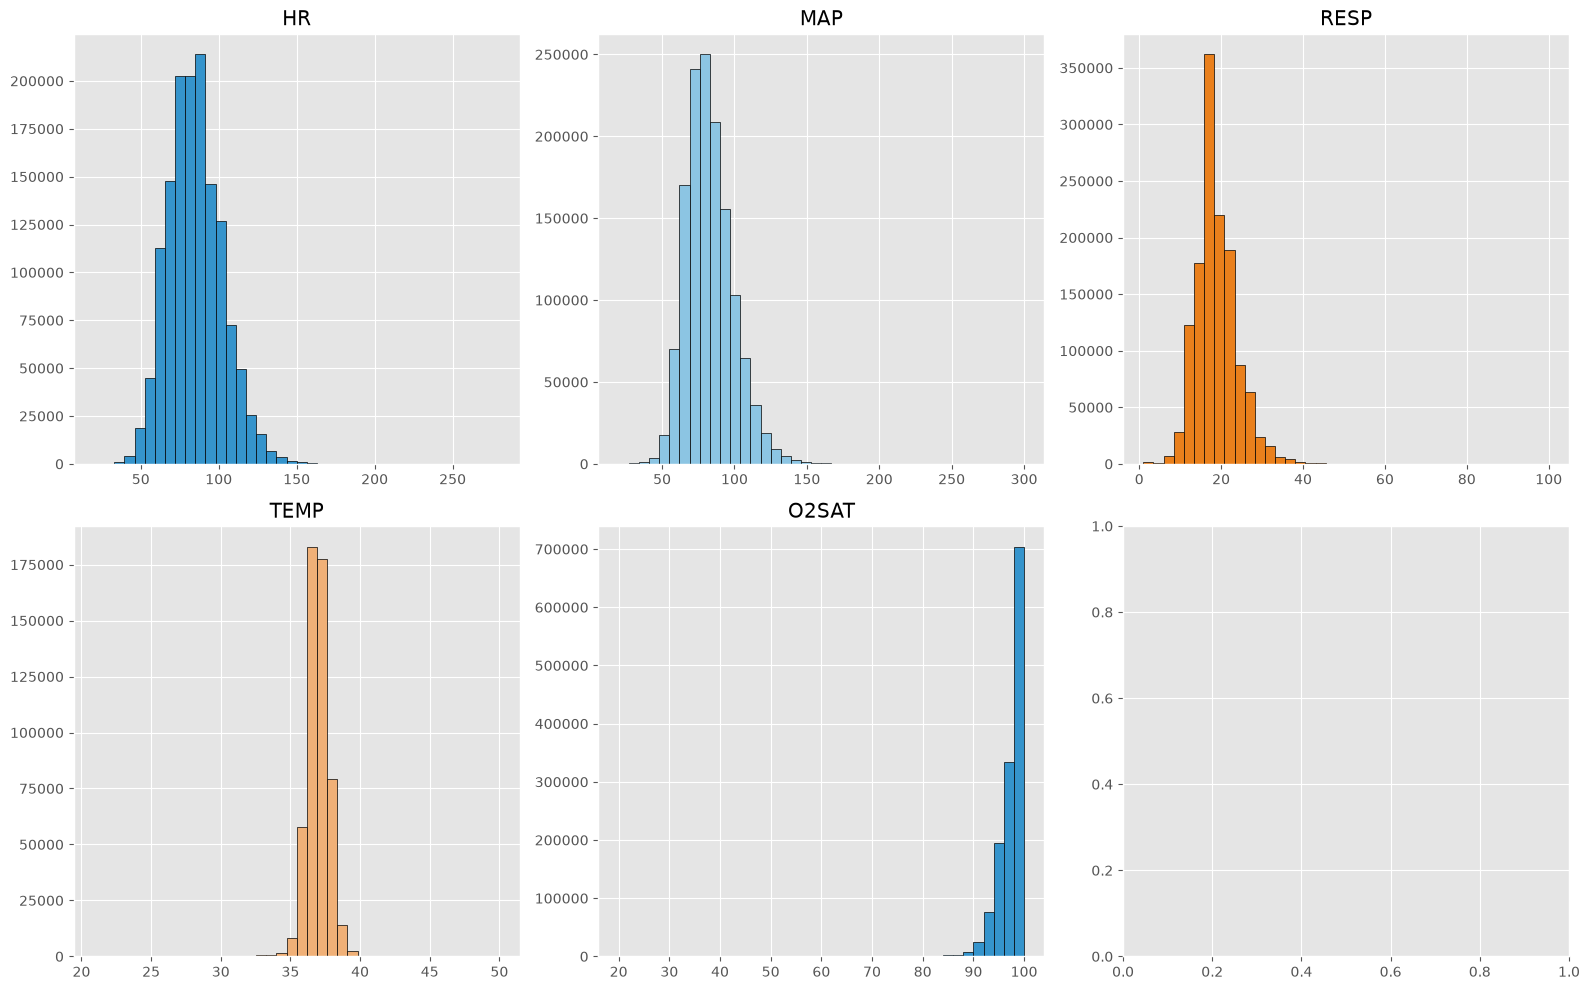

In [21]:
#Vital Sign Distributions
vitals_to_plot = ["hr", "map", "resp", "temp", "o2sat"]

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(vitals_to_plot):
    axes[i].hist(measurements[col].dropna(), bins=40, color=colors[i % len(colors)], edgecolor="black")
    axes[i].set_title(col.upper())

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "vital_sign_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
import seaborn as sns

## 4.3 Correlation Matrix

Pairwise correlation between vital signs, checking for redundancy and physiologically expected relationships
(e.g. HR and Resp).

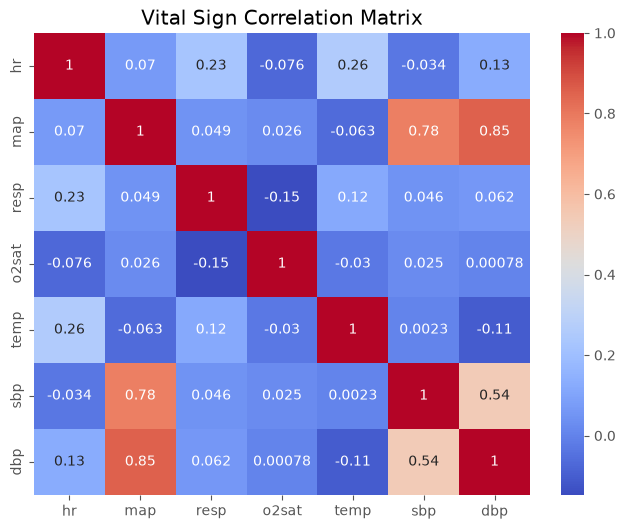

In [23]:
#Correlation Matrix
vitals_corr = measurements[["hr","map","resp","o2sat","temp","sbp","dbp"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(vitals_corr, annot=True, cmap="coolwarm")
plt.title("Vital Sign Correlation Matrix")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "vital_sign_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.4 Patient Trajectories

Hour-by-hour HR, MAP, and Resp trajectories for a random patient versus a sepsis-positive patient, offering
a first visual comparison of stability versus deterioration.

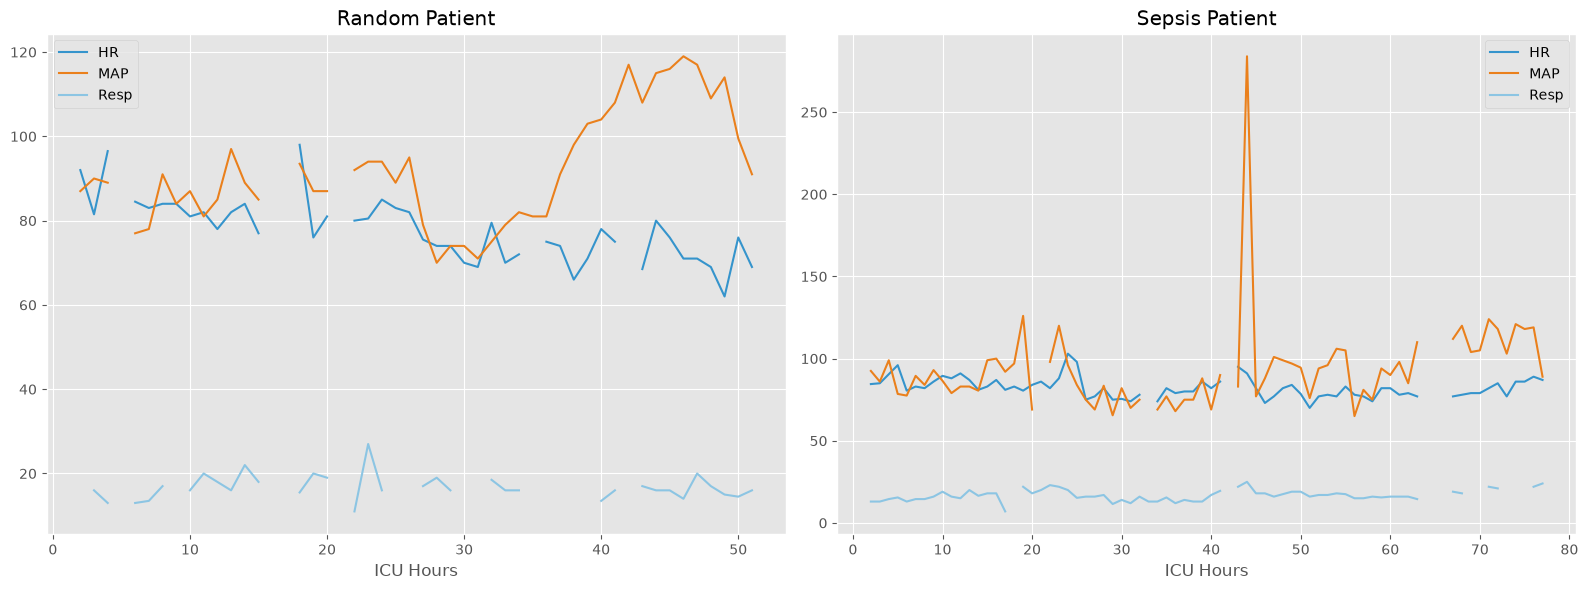

In [24]:
#Patient Trajectories (random vs sepsis)
random_patient = measurements["patient_id"].sample(1, random_state=1).values[0]
sepsis_patient = measurements.loc[measurements["sepsis_label"] == 1, "patient_id"].sample(1, random_state=1).values[0]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

for ax, pid, title in zip(axes, [random_patient, sepsis_patient], ["Random Patient", "Sepsis Patient"]):
    patient = measurements[measurements["patient_id"] == pid].sort_values("iculos")
    ax.plot(patient["iculos"], patient["hr"], color=colors[0], label="HR")
    ax.plot(patient["iculos"], patient["map"], color=colors[2], label="MAP")
    ax.plot(patient["iculos"], patient["resp"], color=colors[1], label="Resp")
    ax.set_title(title)
    ax.set_xlabel("ICU Hours")
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "patient_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.5 Velocity (Rate of Change)

Rather than raw vital sign values, we examine ΔHR, ΔMAP, and ΔResp — the hour-to-hour rate of change.
Sepsis is a trajectory of deterioration, not a single abnormal reading, which is the central justification
for a temporal convolutional (TCN) architecture over static feature models.

In [25]:
#Velocity (ΔHR, ΔMAP, ΔResp)
df["hr_delta"] = df.groupby("patient_id")["hr"].diff()
df["map_delta"] = df.groupby("patient_id")["map"].diff()
df["resp_delta"] = df.groupby("patient_id")["resp"].diff()

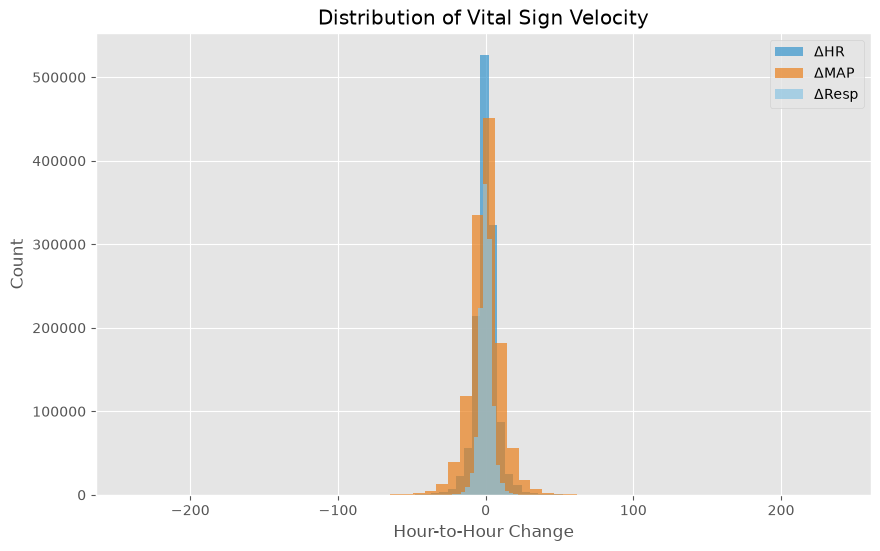

In [26]:
plt.figure(figsize=(10,6))
plt.hist(df["hr_delta"].dropna(), bins=60, color=colors[0], alpha=0.7, label="ΔHR")
plt.hist(df["map_delta"].dropna(), bins=60, color=colors[2], alpha=0.7, label="ΔMAP")
plt.hist(df["resp_delta"].dropna(), bins=60, color=colors[1], alpha=0.7, label="ΔResp")
plt.xlabel("Hour-to-Hour Change")
plt.ylabel("Count")
plt.title("Distribution of Vital Sign Velocity")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "vital_sign_velocity_distribution.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

# 5. Sepsis Analysis

A dedicated section examining the target variable itself: how sepsis is distributed across patients, across
hours, and over time relative to onset.

## 5.1 Patient-Level Class Balance

What proportion of patients in the cohort become septic at any point during their ICU stay?

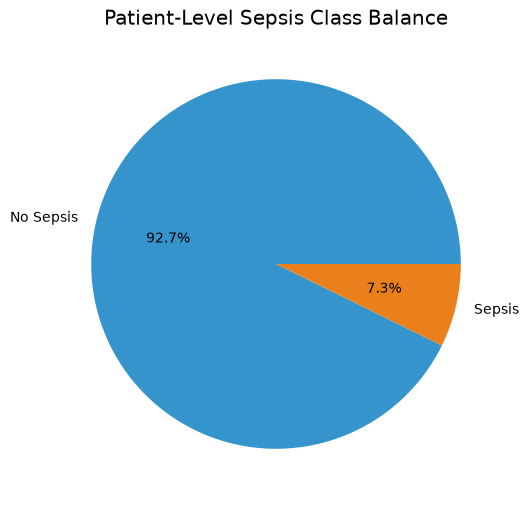

In [27]:
#Sepsis Analysis
# Patient-Level Class Balance
patient_sepsis = measurements.groupby("patient_id")["sepsis_label"].max()
sepsis_counts = patient_sepsis.value_counts()

plt.figure(figsize=(6,6))
plt.pie(sepsis_counts, labels=["No Sepsis", "Sepsis"], autopct="%1.1f%%", colors=[colors[0], colors[2]])
plt.title("Patient-Level Sepsis Class Balance")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "patient_sepsis_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.2 Hour-Level Class Balance

What proportion of individual hourly observations are labeled sepsis-positive? This is typically far more
imbalanced than the patient-level split, and is the class balance that matters for model training.

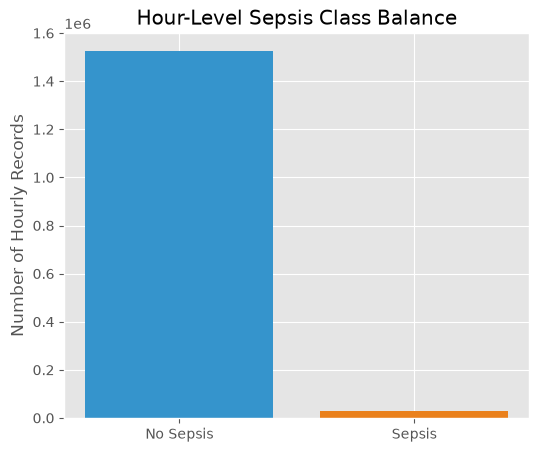

In [28]:
#Hour-Level Class Balance
hour_counts = measurements["sepsis_label"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(["No Sepsis", "Sepsis"], hour_counts.values, color=[colors[0], colors[2]])
plt.ylabel("Number of Hourly Records")
plt.title("Hour-Level Sepsis Class Balance")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "hour_sepsis_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.3 Sepsis Onset Distribution

Distribution of ICULOS at the hour sepsis is first flagged (SepsisLabel == 1). This shows when in a
patient's stay onset tends to occur and supports the forecasting horizon design.

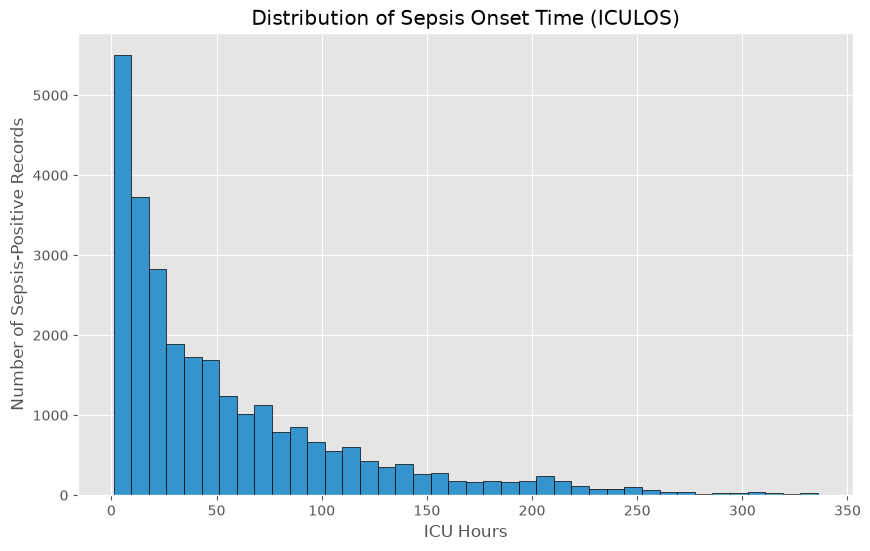

In [29]:
#Sepsis Onset Distribution
onset_hours = measurements.loc[measurements["sepsis_label"] == 1, "iculos"]

plt.figure(figsize=(10,6))
onset_hours.hist(bins=40, color=colors[0], edgecolor="black")
plt.title("Distribution of Sepsis Onset Time (ICULOS)")
plt.xlabel("ICU Hours")
plt.ylabel("Number of Sepsis-Positive Records")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "sepsis_onset_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.4 Hours Before Sepsis Onset

Average HR, MAP, Resp, and Temp in the hours leading up to sepsis onset, aggregated across septic patients.
This traces the pre-onset deterioration pattern directly, supporting the case for trajectory-based embeddings
over single-timepoint features.

In [30]:
#Hours Before Sepsis Onset
sepsis_ids = measurements.loc[measurements["sepsis_label"] == 1, "patient_id"].unique()

records = []

for pid in sepsis_ids:
    patient = measurements[measurements["patient_id"] == pid].sort_values("iculos")
    onset_hour = patient.loc[patient["sepsis_label"] == 1, "iculos"].min()
    patient = patient[patient["iculos"] <= onset_hour].copy()
    patient["hours_before_onset"] = patient["iculos"] - onset_hour
    records.append(patient)

before_onset = pd.concat(records)

In [31]:
window = before_onset[before_onset["hours_before_onset"] >= -24]
trend = window.groupby("hours_before_onset")[["hr","map","resp","temp"]].mean()

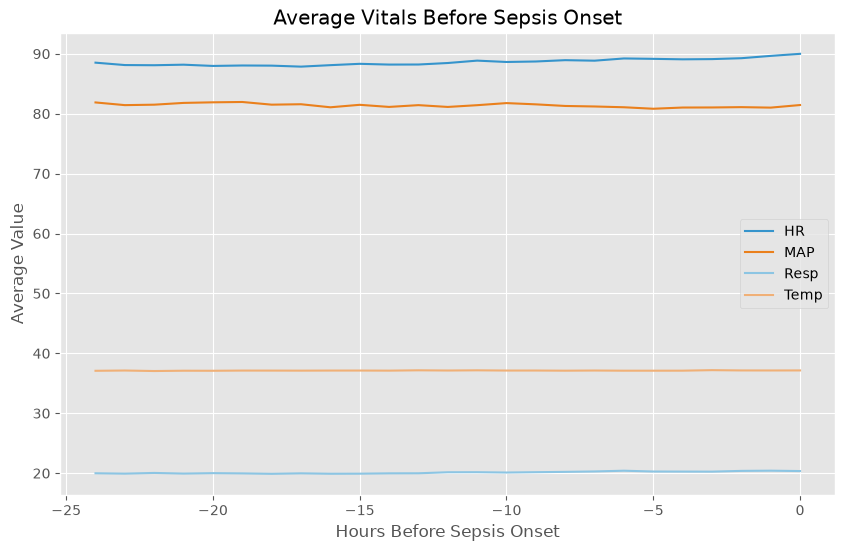

In [32]:
plt.figure(figsize=(10,6))
plt.plot(trend.index, trend["hr"], color=colors[0], label="HR")
plt.plot(trend.index, trend["map"], color=colors[2], label="MAP")
plt.plot(trend.index, trend["resp"], color=colors[1], label="Resp")
plt.plot(trend.index, trend["temp"], color=colors[3], label="Temp")
plt.xlabel("Hours Before Sepsis Onset")
plt.ylabel("Average Value")
plt.title("Average Vitals Before Sepsis Onset")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "vitals_before_sepsis_onset.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

# 6. Pre-Sepsis Physiological Drift

Section 5 showed **when** sepsis tends to occur. This section asks a different question: **how** a patient's
physiology behaves in the hours leading up to that onset.

If deterioration is gradual rather than a single abnormal reading, a model needs to see the *trajectory* of
vitals, not just their most recent value. This is the empirical justification for a **Contrastive Trajectory
Encoder (TCN)**: the architecture should learn to represent the shape of a patient's recent physiological
history, not a static snapshot.

## 6.1 Identify Sepsis Onset

For each patient, we locate the first ICU hour where `sepsis_label == 1`. This gives one onset hour per
septic patient, which anchors all the "hours before onset" alignment that follows.

In [33]:
#Identify Sepsis Onset
sepsis_onset = (
    measurements.loc[measurements["sepsis_label"] == 1]
    .groupby("patient_id")["iculos"]
    .min()
    .reset_index()
)
sepsis_onset.columns = ["patient_id", "onset_hour"]
sepsis_onset.head()

,patient_id,onset_hour
0,9,249
1,11,26
2,15,6
3,18,126
4,22,14


## 6.2 Build Pre-Onset Windows

We align every septic patient's record to their own onset hour (`hours_before_onset = iculos - onset_hour`)
and keep only the 12 hours immediately preceding onset. This is a shorter window than the 24-hour view in
Section 5.4, focused specifically on the near-term deterioration horizon the model will need to forecast.

In [34]:
#Build Pre-Onset Windows (12 hours before onset)
sepsis_ids = sepsis_onset["patient_id"].unique()

records = []
for pid in sepsis_ids:
    patient = measurements[measurements["patient_id"] == pid].sort_values("iculos").copy()
    onset_hour = sepsis_onset.loc[sepsis_onset["patient_id"] == pid, "onset_hour"].values[0]
    patient["hours_before_onset"] = patient["iculos"] - onset_hour
    patient = patient[
        (patient["hours_before_onset"] >= -12) & (patient["hours_before_onset"] <= 0)
    ]
    records.append(patient)

pre_onset_window = pd.concat(records, ignore_index=True)
pre_onset_window.shape

(29256, 38)

## 6.3 Average Pre-Onset Trajectories

For each hour in the 12-hour pre-onset window, we average HR, MAP, Resp, Temp, and O2Sat across all septic
patients. A consistent drift in these averages — rather than a flat line followed by a jump — supports
modeling physiology as a continuous trajectory rather than a set of independent, static features.

In [35]:
#Average Pre-Onset Trajectories
pre_onset_vitals = ["hr", "map", "resp", "temp", "o2sat"]

pre_onset_trend = (
    pre_onset_window.groupby("hours_before_onset")[pre_onset_vitals]
    .mean()
)
pre_onset_trend

,hr,map,resp,temp,o2sat
hours_before_onset,,,,,
-12,88.453984,81.122319,20.153279,37.134007,97.254281
-11,88.851720,81.414734,20.162442,37.166436,97.233018
-10,88.626338,81.764504,20.106775,37.128809,97.236483
-9,88.708050,81.554728,20.165223,37.132003,97.182303
-8,88.929834,81.285804,20.219478,37.106579,97.150186
-7,88.841662,81.199601,20.288524,37.133011,97.066649
-6,89.213580,81.069839,20.410977,37.104033,97.055976
-5,89.148962,80.820414,20.277219,37.104352,97.136905
-4,89.069789,81.022924,20.266917,37.109149,97.094790


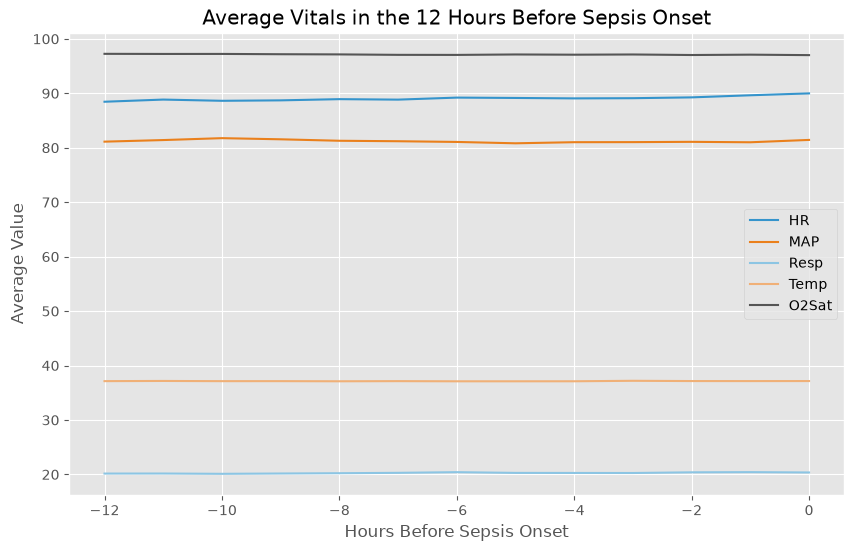

In [36]:
#Multi-line Plot: HR, MAP, Resp, Temp, O2Sat
plt.figure(figsize=(10,6))
plt.plot(pre_onset_trend.index, pre_onset_trend["hr"], color=colors[0], label="HR")
plt.plot(pre_onset_trend.index, pre_onset_trend["map"], color=colors[2], label="MAP")
plt.plot(pre_onset_trend.index, pre_onset_trend["resp"], color=colors[1], label="Resp")
plt.plot(pre_onset_trend.index, pre_onset_trend["temp"], color=colors[3], label="Temp")
plt.plot(pre_onset_trend.index, pre_onset_trend["o2sat"], color="#555555", label="O2Sat")
plt.xlabel("Hours Before Sepsis Onset")
plt.ylabel("Average Value")
plt.title("Average Vitals in the 12 Hours Before Sepsis Onset")
plt.legend()
plt.grid(True)
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "pre_onset_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

## 6.4 Sepsis Onset Timeline

**Objective:** confirm when, in ICU-hours, patients typically become septic.

**Why it matters:** the onset distribution directly supports the choice of a **sliding-window** input and a
**12-hour forecasting horizon** — if onset were concentrated very early or very late in a stay, the windowing
strategy would need to change accordingly.

In [37]:
#Sepsis Onset Timeline - summary statistics
sepsis_onset["onset_hour"].describe()

count    2932.000000
mean       50.896317
std        59.363675
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: onset_hour, dtype: float64

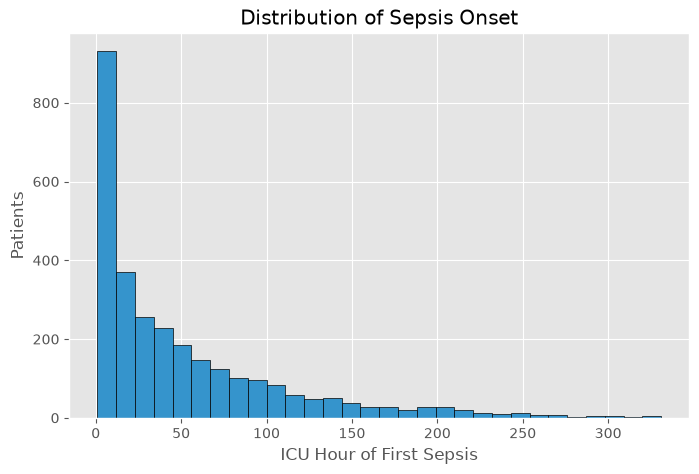

In [38]:
#Histogram of Sepsis Onset Hour
plt.figure(figsize=(8,5))
plt.hist(
    sepsis_onset["onset_hour"],
    bins=30,
    color=colors[0],
    edgecolor="black"
)
plt.xlabel("ICU Hour of First Sepsis")
plt.ylabel("Patients")
plt.title("Distribution of Sepsis Onset")
plt.grid(True)
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "sepsis_onset_timeline_hist.png", dpi=300, bbox_inches="tight")
plt.show()

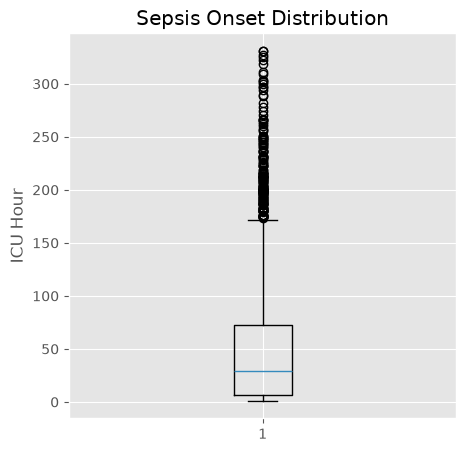

In [39]:
#Boxplot of Sepsis Onset Hour
plt.figure(figsize=(5,5))
plt.boxplot(
    sepsis_onset["onset_hour"]
)
plt.ylabel("ICU Hour")
plt.title("Sepsis Onset Distribution")
plt.savefig(PROJECT_ROOT / "reports" / "eda_figures" / "sepsis_onset_timeline_box.png", dpi=300, bbox_inches="tight")
plt.show()

## 6.5 EDA-to-Architecture Mapping

This table summarizes how each empirical finding from the EDA translates into a specific design decision in
the proposed deep learning architecture.

In [40]:
#EDA-to-Architecture Mapping
architecture = pd.DataFrame({
    "EDA Finding": [
        "Extensive laboratory missingness",
        "Missingness differs by clinical status",
        "Vitals evolve gradually",
        "Long ICU stays",
        "Strong class imbalance",
        "Variable sepsis onset timing",
    ],
    "Architectural Decision": [
        "Missingness Gating Network",
        "Informative Missingness Features",
        "Contrastive Trajectory Encoder (TCN)",
        "Sliding Windows",
        "Weighted Binary Cross Entropy",
        "12-hour Multi-Horizon Prediction",
    ],
})
architecture

,EDA Finding,Architectural Decision
0,Extensive laboratory missingness,Missingness Gating Network
1,Missingness differs by clinical status,Informative Missingness Features
2,Vitals evolve gradually,Contrastive Trajectory Encoder (TCN)
3,Long ICU stays,Sliding Windows
4,Strong class imbalance,Weighted Binary Cross Entropy
5,Variable sepsis onset timing,12-hour Multi-Horizon Prediction


In [41]:
# Check that every clinical measurement has a matching patient record

missing_patients = (
    measurements["patient_id"]
    .isin(patients["patient_id"])
    .value_counts()
)

missing_patients

patient_id
True    1552210
Name: count, dtype: int64

In [42]:
#For the temporal integrity checks
duplicate_hours = (
    measurements
    .groupby(["patient_id", "iculos"])
    .size()
    .reset_index(name="count")
)

duplicate_hours[
    duplicate_hours["count"] > 1
]

,patient_id,iculos,count


In [43]:
#Negative ICU hours
measurements[
    measurements["iculos"] < 0
]

,patient_id,iculos,hr,o2sat,temp,sbp,map,dbp,resp,etco2,baseexcess,hco3,fio2,ph,paco2,sao2,ast,bun,alkalinephos,calcium,chloride,creatinine,bilirubin_direct,glucose,lactate,magnesium,phosphate,potassium,bilirubin_total,troponini,hct,hgb,ptt,wbc,fibrinogen,platelets,sepsis_label


In [44]:
#Patient trajectory length
trajectory_lengths = (
    measurements
    .groupby("patient_id")["iculos"]
    .count()
)

trajectory_lengths.describe()

count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
Name: iculos, dtype: float64

In [45]:
#Are the actual measurements physiologically plausible?
missingness = (
    measurements
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missingness

bilirubin_direct    0.998074
fibrinogen          0.993402
troponini           0.990477
bilirubin_total     0.985092
alkalinephos        0.983932
ast                 0.983776
lactate             0.973299
ptt                 0.970559
sao2                0.965494
etco2               0.962868
phosphate           0.959863
hco3                0.958106
chloride            0.954603
baseexcess          0.945790
paco2               0.944401
calcium             0.941161
platelets           0.940595
creatinine          0.939044
magnesium           0.936896
wbc                 0.935932
bun                 0.931344
ph                  0.930697
hgb                 0.926176
fio2                0.916658
hct                 0.911460
potassium           0.906891
glucose             0.828943
temp                0.661627
dbp                 0.313459
resp                0.153546
sbp                 0.145770
o2sat               0.130611
map                 0.124513
hr                  0.098826
patient_id    

In [46]:
#Missing patient id
patient_missingness = (
    measurements
    .isna()
    .groupby(measurements["patient_id"])
    .mean()
)

patient_missingness.describe()

,patient_id,iculos,hr,o2sat,temp,sbp,map,dbp,resp,etco2,baseexcess,hco3,fio2,ph,paco2,sao2,ast,bun,alkalinephos,calcium,chloride,creatinine,bilirubin_direct,glucose,lactate,magnesium,phosphate,potassium,bilirubin_total,troponini,hct,hgb,ptt,wbc,fibrinogen,platelets,sepsis_label
count,40336.0,40336.0,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.000000,40336.0
mean,0.0,0.0,0.110082,0.142432,0.664265,0.155144,0.137202,0.332229,0.163808,0.971115,0.947102,0.958071,0.923597,0.932229,0.946252,0.965709,0.983484,0.930335,0.983663,0.941421,0.954566,0.938179,0.998108,0.829633,0.974427,0.937418,0.960581,0.906751,0.984765,0.989092,0.910148,0.925402,0.970890,0.934959,0.993843,0.939809,0.0
std,0.0,0.0,0.147824,0.176370,0.224298,0.191994,0.174033,0.372764,0.186772,0.128969,0.104089,0.055523,0.121896,0.112269,0.088529,0.075216,0.030271,0.045893,0.030334,0.046327,0.060246,0.034561,0.010827,0.154617,0.060243,0.047581,0.037346,0.070545,0.026868,0.029444,0.073253,0.054710,0.040847,0.044302,0.024687,0.036172,0.0
min,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.285714,0.000000,0.000000,0.083333,0.083333,0.600000,0.375000,0.600000,0.166667,0.166667,0.550000,0.744681,0.035714,0.083333,0.375000,0.550000,0.166667,0.642857,0.625000,0.166667,0.250000,0.500000,0.333333,0.333333,0.558824,0.0
25%,0.0,0.0,0.027027,0.038462,0.666667,0.041667,0.038462,0.052632,0.043478,1.000000,0.937500,0.930233,0.881356,0.902439,0.921053,0.966667,0.975000,0.916667,0.975000,0.925000,0.928571,0.923077,1.000000,0.771429,0.975000,0.918367,0.944444,0.882353,0.975610,1.000000,0.884615,0.904762,0.952381,0.920000,1.000000,0.925926,0.0
50%,0.0,0.0,0.061224,0.078431,0.750000,0.086207,0.080000,0.131579,0.100000,1.000000,1.000000,0.981481,1.000000,1.000000,1.000000,1.000000,1.000000,0.942857,1.000000,0.948718,0.970588,0.945455,1.000000,0.881089,1.000000,0.946429,0.961538,0.926829,1.000000,1.000000,0.933333,0.941176,0.991967,0.945946,1.000000,0.947368,0.0
75%,0.0,0.0,0.125000,0.166667,0.787879,0.181818,0.161290,0.607843,0.209302,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.956522,1.000000,0.964912,1.000000,0.957447,1.000000,0.942308,1.000000,0.962963,1.000000,0.951220,1.000000,1.000000,0.954545,0.957447,1.000000,0.958333,1.000000,0.959184,0.0
max,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [47]:
#Are measurement patterns different between septic and non-septic patients?
patient_sepsis = (
    measurements
    .groupby("patient_id")["sepsis_label"]
    .max()
)

patient_sepsis.value_counts()

sepsis_label
0    37404
1     2932
Name: count, dtype: int64

In [48]:
patients_without_label = (
    measurements
    .groupby("patient_id")["sepsis_label"]
    .apply(lambda x: x.isna().all())
)

patients_without_label.value_counts()

sepsis_label
False    40336
Name: count, dtype: int64

In [49]:
#Sepsis label distribution at the observation level
measurements["sepsis_label"].value_counts()

sepsis_label
0    1524294
1      27916
Name: count, dtype: int64

In [50]:
measurements["sepsis_label"].value_counts(normalize=True)

sepsis_label
0    0.982015
1    0.017985
Name: proportion, dtype: float64

In [51]:
#When does the first sepsis-positive hour occur in a patient's ICU trajectory?
first_sepsis_hour = (
    measurements[measurements["sepsis_label"] == 1]
    .groupby("patient_id")["iculos"]
    .min()
)

first_sepsis_hour.describe()

count    2932.000000
mean       50.896317
std        59.363675
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: iculos, dtype: float64

In [52]:
#We need to understand whether the positive label appears as a single transition or whether patients have long positive periods.
positive_duration = (
    measurements[measurements["sepsis_label"] == 1]
    .groupby("patient_id")
    .size()
)

positive_duration.describe()

count    2932.000000
mean        9.521146
std         0.805069
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
dtype: float64

In [53]:
#For each patient, identify the first positive hour, then explicitly inspect labels around that transition.
positive = measurements[measurements["sepsis_label"] == 1]

first_positive = (
    positive
    .groupby("patient_id")["iculos"]
    .min()
    .rename("first_positive_hour")
)

check = measurements.merge(
    first_positive,
    on="patient_id",
    how="inner"
)

check["relative_hour"] = (
    check["iculos"] - check["first_positive_hour"]
)

transition_window = check[
    check["relative_hour"].between(-3, 6)
].sort_values(["patient_id", "iculos"])

print(transition_window[
    ["patient_id", "iculos", "sepsis_label", "relative_hour"]
].head(50))

     patient_id  iculos  sepsis_label  relative_hour
248           9     246             0             -3
249           9     247             0             -2
250           9     248             0             -1
251           9     249             1              0
252           9     250             1              1
253           9     251             1              2
254           9     252             1              3
255           9     253             1              4
256           9     254             1              5
257           9     255             1              6
282          11      23             0             -3
283          11      24             0             -2
284          11      25             0             -1
285          11      26             1              0
286          11      27             1              1
287          11      28             1              2
288          11      29             1              3
289          11      30             1         

In [54]:
#Are patient trajectories truly hourly, or are there gaps?
hour_gaps = (
    measurements
    .sort_values(["patient_id", "iculos"])
    .groupby("patient_id")["iculos"]
    .diff()
)

hour_gaps.value_counts().head(10)

iculos
1.0    1511874
Name: count, dtype: int64

In [55]:
#ICU-hour continuity check.
hour_gaps[hour_gaps > 1].value_counts()

Series([], Name: count, dtype: int64)

In [56]:
horizons = [1, 6, 12]

for H in horizons:
    print(f"Testing horizon: {H} hours")

Testing horizon: 1 hours
Testing horizon: 6 hours
Testing horizon: 12 hours


In [57]:
horizons = [1, 6, 12]

for H in horizons:
    
    future_positive_count = 0
    total_prediction_points = 0

    for patient_id, patient_data in measurements.groupby("patient_id"):

        patient_data = patient_data.sort_values("iculos")

        labels = patient_data["sepsis_label"].values

        for t in range(len(labels) - H):

            future_window = labels[t+1:t+H+1]

            total_prediction_points += 1

            if future_window.max() == 1:
                future_positive_count += 1

    print(
        f"Horizon {H}h: "
        f"{future_positive_count:,} positive opportunities / "
        f"{total_prediction_points:,} prediction points"
    )

Horizon 1h: 27,490 positive opportunities / 1,511,874 prediction points
Horizon 6h: 24,403 positive opportunities / 1,310,194 prediction points
Horizon 12h: 20,633 positive opportunities / 1,070,874 prediction points


In [58]:
#Valid sample counts for lookback × horizon
import pandas as pd

lookbacks = [6, 12, 24]
horizons = [1, 6, 12]

results = []

for L in lookbacks:
    for H in horizons:

        total_samples = 0
        positive_targets = 0

        for patient_id, patient_data in measurements.groupby("patient_id"):

            patient_data = patient_data.sort_values("iculos")

            labels = patient_data["sepsis_label"].values
            n_hours = len(labels)

            # prediction point t
            # need L hours history and H hours future
            for t in range(L - 1, n_hours - H):

                total_samples += 1

                future_window = labels[t+1:t+H+1]

                if future_window.max() == 1:
                    positive_targets += 1

        results.append(
            {
                "lookback_hours": L,
                "horizon_hours": H,
                "total_samples": total_samples,
                "positive_samples": positive_targets,
                "positive_rate": positive_targets / total_samples
            }
        )

sample_feasibility = pd.DataFrame(results)

sample_feasibility

,lookback_hours,horizon_hours,total_samples,positive_samples,positive_rate
0,6,1,1310194,24403,0.018625
1,6,6,1110191,21109,0.019014
2,6,12,880023,18515,0.021039
3,12,1,1070874,20633,0.019267
4,12,6,880023,18515,0.021039
5,12,12,675346,16532,0.024479
6,24,1,644685,16251,0.025208
7,24,6,502990,14965,0.029752
8,24,12,349323,13603,0.038941


In [59]:
#Relationship between prediction time and first positive label
#How much warning time exists before the first positive SepsisLabel?
first_positive = (
    measurements[measurements["sepsis_label"] == 1]
    .groupby("patient_id")["iculos"]
    .min()
)

first_positive.head()

patient_id
9     249
11     26
15      6
18    126
22     14
Name: iculos, dtype: int64

In [60]:
#prediction point's distance from that transition
lead_time_records = []

for patient_id, patient_data in measurements.groupby("patient_id"):

    patient_data = patient_data.sort_values("iculos")

    if patient_id not in first_positive.index:
        continue

    onset_label_hour = first_positive.loc[patient_id]

    for _, row in patient_data.iterrows():

        t = row["iculos"]

        lead_time_records.append(
            {
                "patient_id": patient_id,
                "prediction_hour": t,
                "first_positive_hour": onset_label_hour,
                "hours_until_positive": onset_label_hour - t,
                "current_label": row["sepsis_label"]
            }
        )

lead_time_df = pd.DataFrame(lead_time_records)

lead_time_df.head()

,patient_id,prediction_hour,first_positive_hour,hours_until_positive,current_label
0,9,1.0,249,248.0,0.0
1,9,2.0,249,247.0,0.0
2,9,3.0,249,246.0,0.0
3,9,4.0,249,245.0,0.0
4,9,5.0,249,244.0,0.0


In [61]:
lead_time_df[
    lead_time_df["hours_until_positive"] >= 0
]["hours_until_positive"].describe()

count    147426.000000
mean         59.367052
std          55.994198
min           0.000000
25%          17.000000
50%          42.000000
75%          86.000000
max         330.000000
Name: hours_until_positive, dtype: float64

In [62]:
"""Among samples where the future target is positive, 
determine how far before the first positive label the prediction is being made."""

first_positive = (
    measurements[measurements["sepsis_label"] == 1]
    .groupby("patient_id")["iculos"]
    .min()
)

In [63]:
#Generate positive prediction points
positive_lead_records = []

for patient_id, patient_data in measurements.groupby("patient_id"):

    patient_data = patient_data.sort_values("iculos")

    if patient_id not in first_positive.index:
        continue

    patient_data = patient_data.reset_index(drop=True)

    labels = patient_data["sepsis_label"].values
    hours = patient_data["iculos"].values

    first_pos_hour = first_positive.loc[patient_id]

    for i in range(len(labels) - 12):

        current_hour = hours[i]

        for H in [6, 12]:

            future_window = labels[i+1:i+H+1]

            target = int(future_window.max() == 1)

            if target == 1:

                positive_lead_records.append(
                    {
                        "patient_id": patient_id,
                        "prediction_hour": current_hour,
                        "horizon": H,
                        "first_positive_hour": first_pos_hour,
                        "hours_until_positive": first_pos_hour - current_hour
                    }
                )


positive_lead_df = pd.DataFrame(positive_lead_records)

positive_lead_df.head()

,patient_id,prediction_hour,horizon,first_positive_hour,hours_until_positive
0,9,237,12,249,12
1,9,238,12,249,11
2,9,239,12,249,10
3,9,240,12,249,9
4,9,241,12,249,8


In [64]:
#Summarize lead time distribution
positive_lead_df.groupby("horizon")[
    "hours_until_positive"
].describe()

,count,mean,std,min,25%,50%,75%,max
horizon,,,,,,,,
6,8429.0,4.582394,1.079759,3.0,4.0,5.0,6.0,6.0
12,20633.0,7.456938,2.812773,3.0,5.0,7.0,10.0,12.0


In [65]:
#Inspect clinically relevant ranges
for H in [6,12]:

    print(f"\nHorizon {H} hours")

    print(
        positive_lead_df[
            positive_lead_df["horizon"] == H
        ]["hours_until_positive"]
        .value_counts()
        .sort_index()
        .head(15)
    )


Horizon 6 hours
hours_until_positive
3    1704
4    2296
5    2245
6    2184
Name: count, dtype: int64

Horizon 12 hours
hours_until_positive
3     1704
4     2296
5     2245
6     2184
7     2144
8     2094
9     2043
10    2005
11    1979
12    1939
Name: count, dtype: int64


In [66]:
# Confirm actual warehouse columns

measurement_columns = measurements.columns.tolist()

print("Number of columns:", len(measurement_columns))

measurement_columns

Number of columns: 37


['patient_id',
 'iculos',
 'hr',
 'o2sat',
 'temp',
 'sbp',
 'map',
 'dbp',
 'resp',
 'etco2',
 'baseexcess',
 'hco3',
 'fio2',
 'ph',
 'paco2',
 'sao2',
 'ast',
 'bun',
 'alkalinephos',
 'calcium',
 'chloride',
 'creatinine',
 'bilirubin_direct',
 'glucose',
 'lactate',
 'magnesium',
 'phosphate',
 'potassium',
 'bilirubin_total',
 'troponini',
 'hct',
 'hgb',
 'ptt',
 'wbc',
 'fibrinogen',
 'platelets',
 'sepsis_label']

In [67]:
CLINICAL_FEATURES = [
    # Vital signs
    "hr",
    "o2sat",
    "temp",
    "sbp",
    "map",
    "dbp",
    "resp",
    "etco2",

    # Laboratory measurements
    "baseexcess",
    "hco3",
    "fio2",
    "ph",
    "paco2",
    "sao2",
    "ast",
    "bun",
    "alkalinephos",
    "calcium",
    "chloride",
    "creatinine",
    "bilirubin_direct",
    "glucose",
    "lactate",
    "magnesium",
    "phosphate",
    "potassium",
    "bilirubin_total",
    "troponini",
    "hct",
    "hgb",
    "ptt",
    "wbc",
    "fibrinogen",
    "platelets",
]

MISSINGNESS_FEATURES = [
    f"{feature}_missing"
    for feature in CLINICAL_FEATURES
]

TEMPORAL_FEATURES = [
    "iculos"
]

TARGET_COLUMN = "sepsis_label"

In [68]:
#validate the registry
missing_features = [
    feature
    for feature in CLINICAL_FEATURES
    if feature not in measurement_columns
]

print("Missing clinical features:")
print(missing_features)

print("\nClinical feature count:")
print(len(CLINICAL_FEATURES))

Missing clinical features:
[]

Clinical feature count:
34


In [69]:
measurements[CLINICAL_FEATURES].dtypes

hr                  float64
o2sat               float64
temp                float64
sbp                 float64
map                 float64
dbp                 float64
resp                float64
etco2               float64
baseexcess          float64
hco3                float64
fio2                float64
ph                  float64
paco2               float64
sao2                float64
ast                 float64
bun                 float64
alkalinephos        float64
calcium             float64
chloride            float64
creatinine          float64
bilirubin_direct    float64
glucose             float64
lactate             float64
magnesium           float64
phosphate           float64
potassium           float64
bilirubin_total     float64
troponini           float64
hct                 float64
hgb                 float64
ptt                 float64
wbc                 float64
fibrinogen          float64
platelets           float64
dtype: object

In [70]:
#final feature dimension
feature_dimension = (
    len(CLINICAL_FEATURES)
    + len(MISSINGNESS_FEATURES)
    + len(TEMPORAL_FEATURES)
)

print("Final feature dimension:", feature_dimension)

Final feature dimension: 69


In [79]:
#Test the configuration
from feature_config import (
    CLINICAL_FEATURES,
    MISSINGNESS_FEATURES,
    TEMPORAL_FEATURES,
    TARGET_COLUMN,
    LOOKBACK,
    HORIZONS
)

print(len(CLINICAL_FEATURES))
print(len(MISSINGNESS_FEATURES))
print(TEMPORAL_FEATURES)
print(TARGET_COLUMN)
print(LOOKBACK)
print(HORIZONS)

34
34
['iculos']
sepsis_label
12
{'primary': 12, 'secondary': 6}


In [80]:
print("Clinical:", len(CLINICAL_FEATURES))
print("Missingness:", len(MISSINGNESS_FEATURES))
print("Temporal:", len(TEMPORAL_FEATURES))

print("\nClinical features:")
for i, feature in enumerate(CLINICAL_FEATURES, 1):
    print(i, feature)

Clinical: 34
Missingness: 34
Temporal: 1

Clinical features:
1 hr
2 o2sat
3 temp
4 sbp
5 map
6 dbp
7 resp
8 etco2
9 baseexcess
10 hco3
11 fio2
12 ph
13 paco2
14 sao2
15 ast
16 bun
17 alkalinephos
18 calcium
19 chloride
20 creatinine
21 bilirubin_direct
22 glucose
23 lactate
24 magnesium
25 phosphate
26 potassium
27 bilirubin_total
28 troponini
29 hct
30 hgb
31 ptt
32 wbc
33 fibrinogen
34 platelets


In [82]:
from build_features import build_feature_table, validate_feature_table

feature_table = build_feature_table(measurements)

feature_table.head()

,patient_id,iculos,hr,o2sat,temp,sbp,map,dbp,resp,etco2,baseexcess,hco3,fio2,ph,paco2,sao2,ast,bun,alkalinephos,calcium,chloride,creatinine,bilirubin_direct,glucose,lactate,magnesium,phosphate,potassium,bilirubin_total,troponini,hct,hgb,ptt,wbc,fibrinogen,platelets,hr_missing,o2sat_missing,temp_missing,sbp_missing,map_missing,dbp_missing,resp_missing,etco2_missing,baseexcess_missing,hco3_missing,fio2_missing,ph_missing,paco2_missing,sao2_missing,ast_missing,bun_missing,alkalinephos_missing,calcium_missing,chloride_missing,creatinine_missing,bilirubin_direct_missing,glucose_missing,lactate_missing,magnesium_missing,phosphate_missing,potassium_missing,bilirubin_total_missing,troponini_missing,hct_missing,hgb_missing,ptt_missing,wbc_missing,fibrinogen_missing,platelets_missing,sepsis_label
0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
1,1,2,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
2,1,3,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
3,1,4,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,1,1,0,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
4,1,5,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0


In [83]:
feature_table.shape

(1552210, 71)

In [84]:
feature_table[MISSINGNESS_FEATURES].nunique().sort_values()

hr_missing                  2
o2sat_missing               2
temp_missing                2
sbp_missing                 2
map_missing                 2
dbp_missing                 2
resp_missing                2
etco2_missing               2
baseexcess_missing          2
hco3_missing                2
fio2_missing                2
ph_missing                  2
paco2_missing               2
sao2_missing                2
ast_missing                 2
bun_missing                 2
alkalinephos_missing        2
calcium_missing             2
chloride_missing            2
creatinine_missing          2
bilirubin_direct_missing    2
glucose_missing             2
lactate_missing             2
magnesium_missing           2
phosphate_missing           2
potassium_missing           2
bilirubin_total_missing     2
troponini_missing           2
hct_missing                 2
hgb_missing                 2
ptt_missing                 2
wbc_missing                 2
fibrinogen_missing          2
platelets_

In [86]:
feature_table.columns.tolist()

['patient_id',
 'iculos',
 'hr',
 'o2sat',
 'temp',
 'sbp',
 'map',
 'dbp',
 'resp',
 'etco2',
 'baseexcess',
 'hco3',
 'fio2',
 'ph',
 'paco2',
 'sao2',
 'ast',
 'bun',
 'alkalinephos',
 'calcium',
 'chloride',
 'creatinine',
 'bilirubin_direct',
 'glucose',
 'lactate',
 'magnesium',
 'phosphate',
 'potassium',
 'bilirubin_total',
 'troponini',
 'hct',
 'hgb',
 'ptt',
 'wbc',
 'fibrinogen',
 'platelets',
 'hr_missing',
 'o2sat_missing',
 'temp_missing',
 'sbp_missing',
 'map_missing',
 'dbp_missing',
 'resp_missing',
 'etco2_missing',
 'baseexcess_missing',
 'hco3_missing',
 'fio2_missing',
 'ph_missing',
 'paco2_missing',
 'sao2_missing',
 'ast_missing',
 'bun_missing',
 'alkalinephos_missing',
 'calcium_missing',
 'chloride_missing',
 'creatinine_missing',
 'bilirubin_direct_missing',
 'glucose_missing',
 'lactate_missing',
 'magnesium_missing',
 'phosphate_missing',
 'potassium_missing',
 'bilirubin_total_missing',
 'troponini_missing',
 'hct_missing',
 'hgb_missing',
 'ptt_missing

In [87]:
#check feature table ordering
feature_table = feature_table.sort_values(
    ["patient_id", "iculos"]
).reset_index(drop=True)


feature_table.head(15)

,patient_id,iculos,hr,o2sat,temp,sbp,map,dbp,resp,etco2,baseexcess,hco3,fio2,ph,paco2,sao2,ast,bun,alkalinephos,calcium,chloride,creatinine,bilirubin_direct,glucose,lactate,magnesium,phosphate,potassium,bilirubin_total,troponini,hct,hgb,ptt,wbc,fibrinogen,platelets,hr_missing,o2sat_missing,temp_missing,sbp_missing,map_missing,dbp_missing,resp_missing,etco2_missing,baseexcess_missing,hco3_missing,fio2_missing,ph_missing,paco2_missing,sao2_missing,ast_missing,bun_missing,alkalinephos_missing,calcium_missing,chloride_missing,creatinine_missing,bilirubin_direct_missing,glucose_missing,lactate_missing,magnesium_missing,phosphate_missing,potassium_missing,bilirubin_total_missing,troponini_missing,hct_missing,hgb_missing,ptt_missing,wbc_missing,fibrinogen_missing,platelets_missing,sepsis_label
0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
1,1,2,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
2,1,3,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
3,1,4,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,1,1,0,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
4,1,5,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
5,1,6,110.0,91.0,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
6,1,7,108.0,92.0,36.11,123.0,77.00,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
7,1,8,106.0,90.5,NaN,93.0,76.33,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
8,1,9,104.0,95.0,NaN,133.0,88.33,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
9,1,10,102.0,91.0,NaN,134.0,87.33,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0


In [89]:
feature_table.head(10).to_csv("feature_table.csv", index=False)